In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
from experiment_modules import *
from numpy.testing import assert_array_equal

import matplotlib.pyplot as plt
import seaborn as sns

from copy import deepcopy
from rich.progress import track

2023-08-31 16:56:38.896633: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2023-08-31 16:56:46.907806: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


Using backend: cpu

Available hardware:

TFRT_CPU_0

In [3]:
rng = jax.random.PRNGKey(0)
generator = Generator(50)

In [4]:
def calculate_entropy_from_model(state, generator=generator):
    """
    Compute the entropy of a model on some data.
    """
    ntk_fn = get_ntk_function(state.apply_fn, None)

    ntk_matrix = ntk_fn(
                    generator.train_ds["inputs"],
                    generator.train_ds["inputs"],
                    {"params": state.params}
                )

    return compute_entropy(ntk_matrix)    

# Layer Addition

In [357]:
nodes = 10

one_layer = build_network(nodes, 1)()
one_state = create_train_state(one_layer, rng, 1e-3)

two_layer = build_network(nodes, 2)()
two_state = create_train_state(two_layer, rng, 1e-3)

three_layer = build_network(nodes, 3)()
three_state = create_train_state(three_layer, rng, 1e-3)

four_layer = build_network(nodes, 4)()
four_state = create_train_state(four_layer, rng, 1e-3)

five_layer = build_network(nodes, 5)()
five_state = create_train_state(five_layer, rng, 1e-3)

six_layer = build_network(nodes, 6)()
six_state = create_train_state(six_layer, rng, 1e-3)

ten_layer = build_network(nodes, 10)()
ten_state = create_train_state(ten_layer, rng, 1e-3)

In [358]:
# Consistency check
assert_array_equal(
    one_state.params["hidden_layers_0"]["Dense_0"]["kernel"],
    two_state.params["hidden_layers_0"]["Dense_0"]["kernel"]
)
assert_array_equal(
    one_state.params["hidden_layers_0"]["Dense_0"]["kernel"],
    three_state.params["hidden_layers_0"]["Dense_0"]["kernel"]
)
assert_array_equal(
    two_state.params["hidden_layers_1"]["Dense_0"]["kernel"],
    three_state.params["hidden_layers_1"]["Dense_0"]["kernel"]
)

In [359]:
one_entropy = calculate_entropy_from_model(one_state)
two_entropy = calculate_entropy_from_model(two_state)
three_entropy = calculate_entropy_from_model(three_state)
four_entropy = calculate_entropy_from_model(four_state)
five_entropy = calculate_entropy_from_model(five_state)
six_entropy = calculate_entropy_from_model(six_state)
ten_entropy = calculate_entropy_from_model(ten_state)

Text(0, 0.5, 'Entropy')

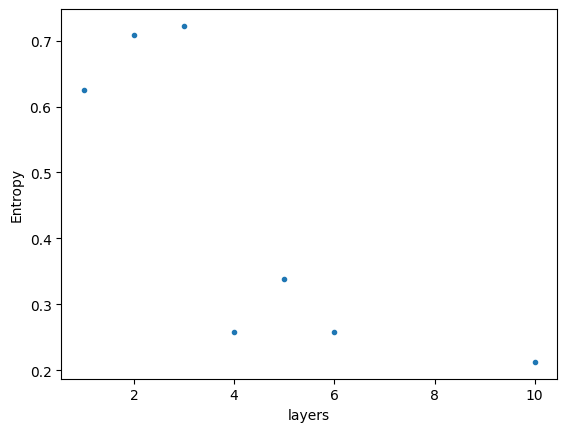

In [360]:
plt.plot(
    [1, 2, 3, 4, 5, 6, 10],
    [one_entropy, two_entropy, three_entropy, four_entropy, five_entropy, six_entropy, ten_entropy], 
    '.'
)

plt.xlabel("layers")
plt.ylabel("Entropy")

# Node Addition

In [361]:
layers = 10

units = [1, 10, 100, 1000]
states_arrays = []

for width in units:
    model = build_network(width, layers)()
    states_arrays.append(
        create_train_state(model, rng, 1e-3)
    )

In [362]:
entropies = []

for state in states_arrays:
    entropies.append(
        calculate_entropy_from_model(state))

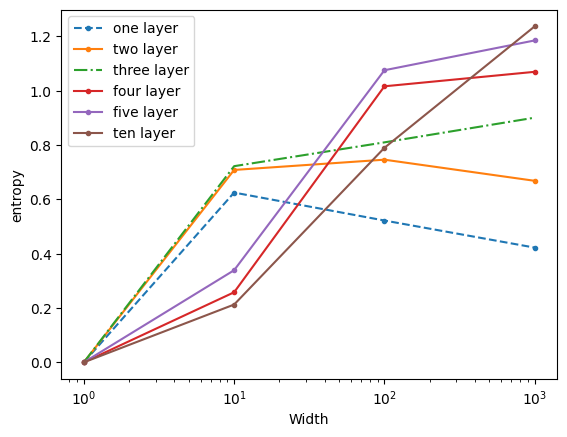

In [370]:
plt.plot(units, one_layer_entropy, '.--', label="one layer")
plt.plot(units, two_layer_entropy, '.-', label="two layer")
plt.plot(units, three_layer_entropy, '-.', label="three layer")
plt.plot(units, four_layer_entropy, '.-', label="four layer")
plt.plot(units, five_layer_entropy, '.-', label="five layer")
plt.plot(units, ten_layer_entropy, '.-', label="ten layer")

plt.xscale("log")

plt.xlabel("Width")
plt.ylabel("entropy")
plt.legend()
plt.show()

In [325]:
one_layer_entropy = copy.deepcopy(entropies)

In [328]:
two_layer_entropy = copy.deepcopy(entropies)

In [347]:
three_layer_entropy = copy.deepcopy(entropies)

In [351]:
four_layer_entropy = copy.deepcopy(entropies)

In [338]:
five_layer_entropy = copy.deepcopy(entropies)

In [363]:
ten_layer_entropy = copy.deepcopy(entropies)

In [366]:
np.log(2)

0.6931471805599453

# Mutual Information

In [5]:
width = 2000
rng = jax.random.PRNGKey(68465)

In [6]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
entropy = []

for depth in track(depths):
    model = build_network(width, depth)()
    model_state = create_train_state(model, rng, 1e-3)

    if depth >  2:
        for i in range(depth - 2):
            model_state.params[f"hidden_layers_{i + 2}"] = model_state.params[f"hidden_layers_1"]

    entropy.append(
        calculate_entropy_from_model(model_state)
    )

Output()

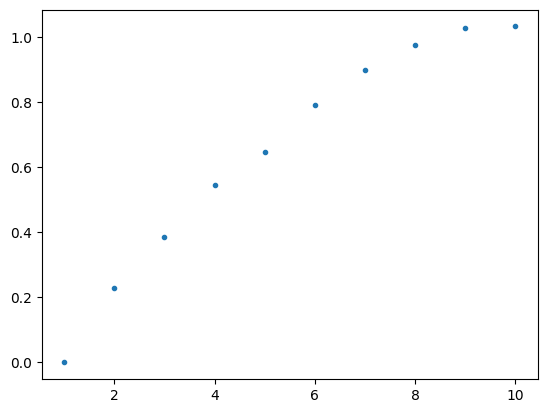

In [7]:
plt.plot(depths, entropy - entropy[0], '.')

<Axes: ylabel='Density'>

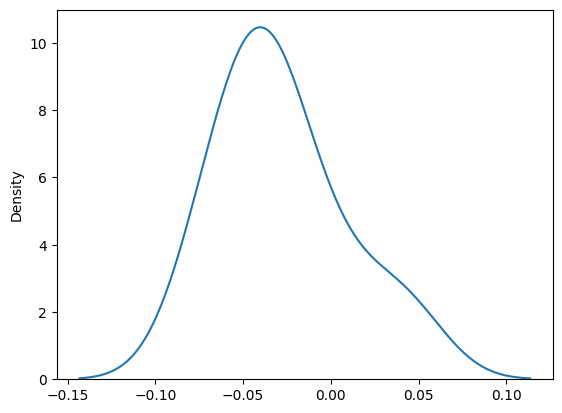

In [8]:
sns.kdeplot(np.diff(np.diff(entropy - entropy[0])))

<Axes: ylabel='Count'>

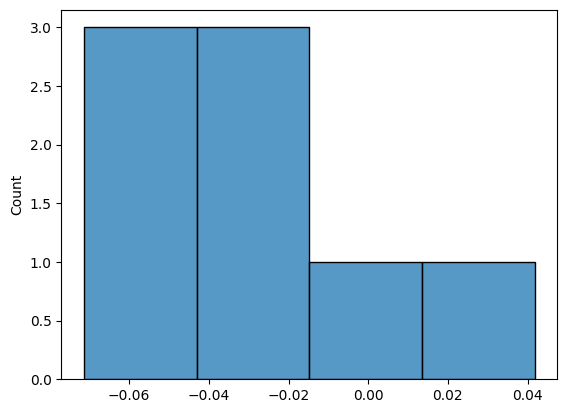

In [9]:
sns.histplot(np.diff(np.diff(entropy - entropy[0])))

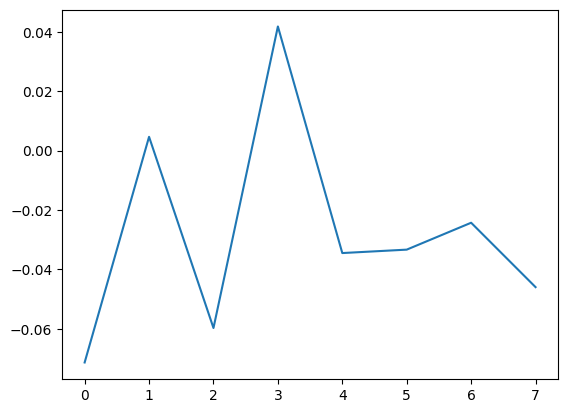

In [10]:
plt.plot(np.diff(np.diff(entropy - entropy[0])))